# Introduction to Compartment Models

Compartment models are a type of mathematical model used in epidemiology, physics, chemistry, biology, and economics to simplify the mathematical modelling of continuous flows between various disjoint states. They are called "compartment models" because they divide the subject of the model into compartments, with assumptions about the interactions between these compartments.
Compartment models are especially popular for modelling the spread of disease.

Typically, compartment models are specified by defining flow rates (derivatives with respect to time!!) in and out of each compartment. That is, each compartment is defined in terms of a differential equation, giving a system of intertwined differential equations. While it is sometimes possible to solve these systems explicitly in very simple models, most systems require us to solve them numerically, as we will do in this notebook. We will use package called SciPy, and an function called ODEint (ODE= Ordinary Differential Equation) to numerically solve our systems.

The simplest form of a compartment model is the SIR model, where S stands for susceptible, I for infectious, and R for recovered. These models are used to simulate how diseases spread through populations.

You can read more here: https://en.wikipedia.org/wiki/Compartmental_models_in_epidemiology


## The SIR Model Explained

The SIR model divides the population into three compartments:

- **S (Susceptible):** The segment of the population that is not yet infected with the disease but can become infected.
- **I (Infectious):** The segment of the population that is currently infected with the disease and can transmit it to susceptible individuals.
- **R (Recovered):** The segment of the population that has recovered from the disease and now has immunity to it.

The model is governed by the following differential equations:

$$
\begin{align*}
\frac{dS}{dt} &= -\beta S\frac{I}{N}, \\
\frac{dI}{dt} &= \beta S\frac{I}{N} - \gamma I, \\
\frac{dR}{dt} &= \gamma I,
\end{align*}
$$

where:
- $N$ is the total population (constant),
- $\beta$ is the transmission rate (probability of infection per exposure),
- $\gamma$ is the recovery rate.

Every term should be thought of as a ***rate***. Flow out of a compartment is represented by negative terms and flow into a compartment is given by positive terms. For example, the flow rate ***OUT*** of the $S$ compartment is $-\beta S(I/N)$ and those individuals are flowing ***IN*** to the $I$ compartment is $\beta S(I/N)$.

When defining your equations, it's important that the model is **balanced**, that is to say that flows out of a compartment must equal flow into a compartment (or sum of flows into compartments, if the flow out of a compartment splits to flow into several compartments). 

Notice that the term $I/N$ is the proportion of the population infected at time $t$, and so you can think of $\beta S(I/N)$ as being the number of susceptible people ($S$), times the probability of being exposed ($I/N$), times the probability that that a given exposure will lead to an infection ($\beta$).

This is a very simple model that does not include births or deaths, but it can be expanded to include these things. 





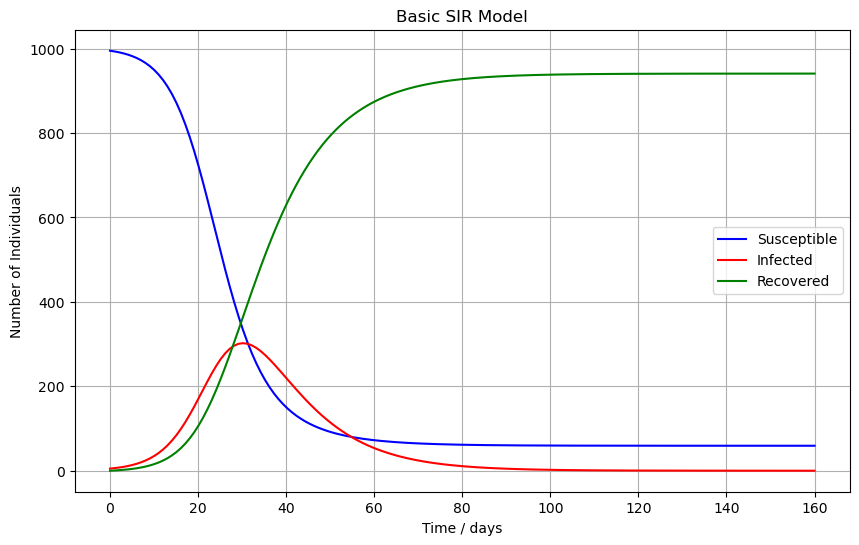

In [5]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters
N = 1000  # total population (usually you want the population to be fairly big)
I0 = 5    # initial number of infected individuals
R0 = 0    # initial number of recovered individuals
S0 = N - I0 - R0  # initial number of susceptible individuals
#Note: at any time we should have N=S+I+R
beta = 0.3  # transmission rate
gamma = 0.1  # recovery rate

# SIR model differential equations.
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Time vector
t = np.linspace(0, 160, 160)

# Initial conditions vector
y0 = S0, I0, R0

# Integrate the SIR equations over time t
# This uses the odeint numerical integration function from the scipy package.
ret = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = ret.T #Transpose the vector

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t, S, 'b', label='Susceptible')
plt.plot(t, I, 'r', label='Infected')
plt.plot(t, R, 'g', label='Recovered')
plt.title('Basic SIR Model')
plt.xlabel('Time / days')
plt.ylabel('Number of Individuals')
plt.legend()
plt.grid(True)
plt.show()


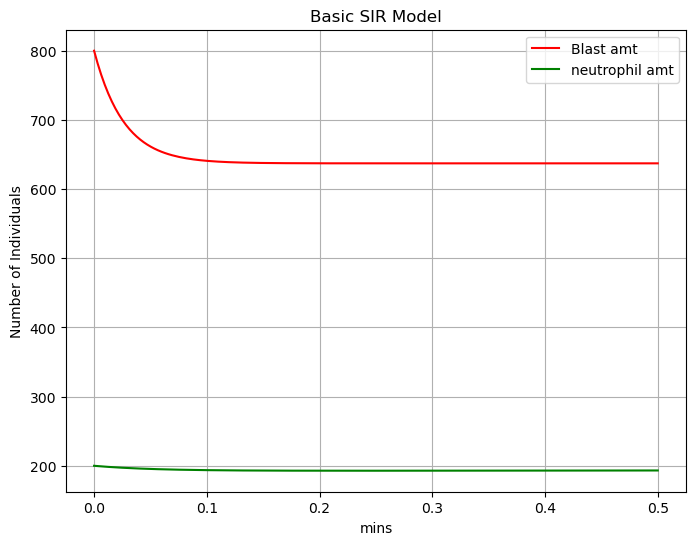

In [20]:
''' Xad = concentration of deposited azatadine 
    Xac = concentration of of azacitidine in central system
    dXaddt = -Ka*Xad
    Xac = Ka*Xad - (CLa/V2a)Xac
    
    '''

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
'''
# Parameters
N = 1000  # total population (usually you want the population to be fairly big)
I0 = 5    # initial number of infected individuals
R0 = 0    # initial number of recovered individuals
S0 = N - I0 - R0  # initial number of susceptible individuals
#Note: at any time we should have N=S+I+R
beta = 0.3  # transmission rate
gamma = 0.1  # recovery rate
'''

'''
N = total population of cells
b= growth rate of blast cells
E = effect of azacitidine
	= A*(1.1)
A = initial amount of azacitidine
W = population of neutrophils
B = population of blast cells
g = growth rate of neutrophils
k = clearance rate of azacitidine

'''
N =1000
A0 = 75 # the usuall dose is 75mg/m^2 for seven days  so 75*7
B0 = 800
W0 = N -B0 #This means that neutrophil population is dependant on Blast population
k = 20 #the rate at which azacitidine becomes ineffective? assume it takes 28 days for 525 mg to become ineffective
b = 0.1
g = 0.651 #Feedback of neutrophil level on stem cell proliferation
H = 4.67 #Equilibrium level of healthy neutrophils

def neutrophil_Def(y,t, Ewbc, Xwbc,B = 4.67,gam=0.651,ktr = 0.236): # Nucleophil differentiation in three compartment model
    Xpr, Xtr,Xwbc = y
    kwbc = 2.3765 
    if Xpr+Xl1 < 4*4.67/kwbc:
        dc = 0
    else:
        dc = Xpr+Xl1 - (4*4.67/kwbc)
    
    F = ktr*((B/Xwbc)**gam)*(1-Ewbc) #proliferation rate (of neutrophils?)
    G = ktr # differentiation rate
    dXprdt = Xpr*(F-G -dc) #change in concentration of proliferating cells in blood, 
    #dc =  represents the rate of cell death due to the effects of leukemic blasts
    dXtrdt = G*Xpr - G*Xtr#change in concentration of transition cells in blood
    dXwbcdt = G*Xtr - 
    #dXwbcdt = G*Xtr - kwbc*Xwbc # change in concentration of mature neutrophils in blood
    return [dXprdt,dXtrdt,dXwbcdt]

def model(y,t,N,H,k,b,g):
    A,B,W = y
    E = A*(1.1)
    dAdt = A - k*(A)
    dBdt = b*(B)*(1/N) - (E*A)
    dWdt = -b*(B)*(1/N) + 
    #dWdt = -b*(B)*(1/N) +  (1-E)*k*((H/W)**g)
    return[dAdt,dBdt,dWdt]

y0 = A0,B0,W0

t=  np.linspace(0, 0.5, 160)
ret = odeint(model, y0, t, args=(N, H, k,b,g))
A,B,W = ret.T #Transpose the vector

'''
# SIR model differential equations.
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Time vector
t = np.linspace(0, 160, 160)

# Initial conditions vector
y0 = S0, I0, R0

# Integrate the SIR equations over time t
# This uses the odeint numerical integration function from the scipy package.
ret = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = ret.T #Transpose the vector
'''
# Plotting
#plt.figure(figsize=(10, 6))
fig, ax1 = plt.subplots(figsize=(8, 6))
#ax2=ax1.twinx()
#ax2.plot(t, A, 'b', label='Aza conct')
ax1.plot(t, B, 'r', label='Blast amt')
ax1.plot(t, W, 'g', label='neutrophil amt')
#ax2.set_ylim(0,100)
#ax1.set_ylim(0,1000)
#plt.plot(t, A, 'b', label='Aza conct')

plt.title('Basic SIR Model')
plt.xlabel('mins')
plt.ylabel('Number of Individuals')
ax1.legend()
ax2.legend()
plt.grid(True)
plt.show()


Try to think about the following ideas (they may be useful for your RP):  

1. Modify the initial number of infected individuals (`I0`) and observe how the dynamics change. What happens if you change `I0` to 0, 10, 50, or 100?
2. Change the transmission rate (`beta`) and recovery rate (`gamma`) to simulate different scenarios of disease spread and control measures. How does increasing or decreasing these rates affect the epidemic curve?
3. Consider introducing a new compartment, `E` (Exposed), for individuals who have been exposed to the disease but are not yet infectious. How would you modify the model and the differential equations to include this compartment? The modified model is called an **SEIR** model.


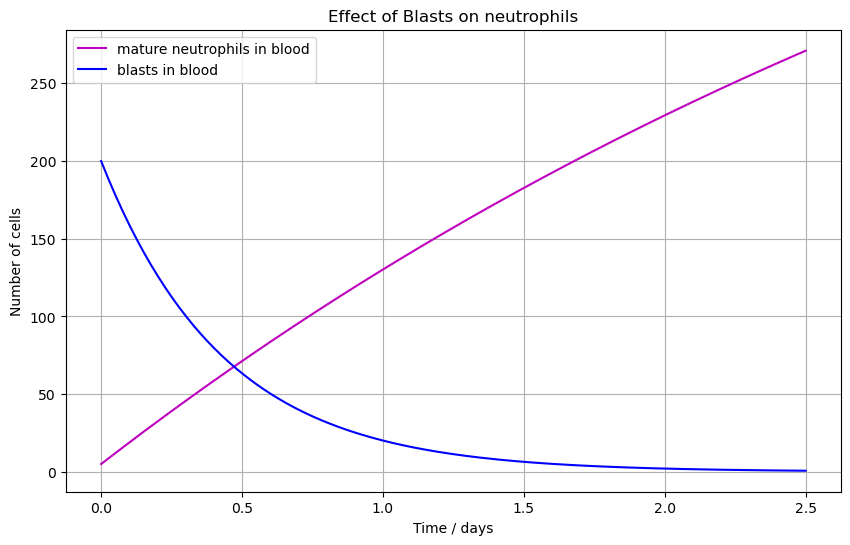

In [34]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
slopeWbc = 1.1
slopeBlast = 1.1
I = 75*(10**-3)
Ewbc = slopeWbc*I
Eblast = slopeBlast*I
N =1000
Xl1 = 1
Xl2 = 200

Xwbc = 5
Xpr = 200
Xtr = N-Xwbc-Xpr-Xl1-Xl2
Xad = 2*(10**-6)
Xac = 2*(10**-6)


def neutrophil_Def(y,t, Ewbc, Xwbc,B = 4.67,gam=0.651,ktr = 0.236): # Nucleophil differentiation in three compartment model
    Xpr, Xtr,Xwbc = y
    kwbc = 2.3765 
    F = ktr*((B/Xwbc)**gam)*(1-Ewbc) #proliferation rate (of neutrophils?)
    G = ktr # differentiation rate
    dXprdt = Xpr*(F-G) #change in concentration of proliferating cells in blood, 
    #dc =  represents the rate of cell death due to the effects of leukemic blasts
    dXtrdt = G*Xpr - G*Xtr#change in concentration of transition cells in blood
    dXwbcdt = G*Xtr
    #dXwbcdt = G*Xtr - kwbc*Xwbc # change in concentration of mature neutrophils in blood
    return [dXprdt,dXtrdt,dXwbcdt]






def blast_pop(y,t,Xwbc,Eblast,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):#Blast population model in two compartments
     Xl1,Xl2 = y
     klc = 1/(1+c1*Xwbc+c2*Xl2) #the suppressive influence from nuetrophils and blasts in the blood
     dXl1dt = (2*a1*klc - 1 - Eblast)*Xl1*p1 #change in leukemia cells in bone marrow 
     dXl2dt = 2*(1-a1*klc)*p1*Xl1 - (d2*Xl2) #change in leukemia cells in blood
     return [dXl1dt, dXl2dt]

def model(y,t, Ewbc, Eblast, Xwbc):
    Xpr, Xtr,Xwbc,Xl1,Xl2 = y
    B = 4.67 #Equilibrium level of healthy neutrophils
    gam=0.651 #feedback of neutrophil level on stem cell proliferation, 0.651
    ktr = 0.236 #death rate of neutrophil lineage,  0.236
    c1 = 0.1 #factor that modulates cytokine feedback, 0.1
    c2 =0.1 #factor that modulates cytokine feedback, 0.1
    p1 = 0.1 #growth rate of leukemic cells, 0.1
    a1 = 0.875 #Fraction of self-renewal of leukemic cells, 0.875
    d2 = 2.3 #death rate of blasts in blood, 2.3
    kwbc = 2.3765 
    F = ktr*((B/Xwbc)**gam)*(1-Ewbc) #proliferation rate (of neutrophils?)
    G = ktr # differentiation rate
    if (Xpr+Xl1) < (4*B/kwbc): # this means that cells will only start dying once there is a certain amount of leukemic blasts
        dc = 0 
    else:
        dc = Xpr+Xl1 - (4*B/kwbc)
    dXprdt = Xpr*(F-G - dc) #change in concentration of proliferating cells in blood, 
    
    #dc =  represents the rate of cell death due to the effects of leukemic blasts
    dXtrdt = G*Xpr - G*Xtr#change in concentration of transition cells in blood
    dXwbcdt = G*Xtr ## change in concentration of mature neutrophils in blood
    #dXwbcdt = G*Xtr - kwbc*Xwbc # change in concentration of mature neutrophils in blood but with death involved

    klc = 1/(1+c1*Xwbc+c2*Xl2) #the suppressive influence from nuetrophils and blasts in the blood
    dXl1dt = ((2*a1*klc) - 1 - Eblast)*Xl1*p1 #change in leukemia cells in bone marrow 
    dXl2dt = 2*(1-a1*klc)*p1*Xl1 - (d2*Xl2) #change in leukemia cells in blood
    return [dXprdt,dXtrdt,dXwbcdt,dXl1dt,dXl2dt ]
    
    
t = np.linspace(0, 2.5, 200)    
y0n = Xpr, Xtr,Xwbc,Xl1,Xl2
ret = odeint(model,y0n,t, args= (Ewbc,Eblast,Xwbc))
Xpr, Xtr,Xwbc,Xl1,Xl2 = ret.T
plt.figure(figsize=(10, 6))
#plt.plot(t, Xpr, 'g', label=' proliferating cells in blood')
#plt.plot(t, Xtr, 'r', label='transition cells in blood')
plt.plot(t, Xwbc, 'm', label='mature neutrophils in blood')
#plt.plot(t, Xl1, 'r', label='blasts in marrow')
plt.plot(t, Xl2, 'b', label='blasts in blood')
plt.title('Effect of Blasts on neutrophils')
plt.xlabel('Time / days')
plt.ylabel('Number of cells')
plt.legend()
plt.grid(True)
plt.show()

## Introduction to the SIRD Model

The SIRD model extends the basic SIR model by adding a 'Deceased' compartment, representing individuals who have died from the disease. This model provides a more comprehensive view of an epidemic's impact by accounting for mortality directly caused by the infection. The compartments in this model are:

- **S (Susceptible):** Individuals not yet infected with the disease.
- **I (Infectious):** Currently infected individuals who can transmit the disease to susceptible individuals.
- **R (Recovered):** Individuals who have recovered from the disease and have immunity.
- **D (Deceased):** Individuals who have died from the disease.

The differential equations governing the SIRD model are:

$$
\begin{align*}
\frac{dS}{dt} &= -\beta \frac{SI}{N}, \\
\frac{dI}{dt} &= \beta \frac{SI}{N} - \gamma I - \delta I, \\
\frac{dR}{dt} &= \gamma I, \\
\frac{dD}{dt} &= \delta I,
\end{align*}
$$

where:
- $\beta$ is the rate of transmission,
- $\gamma$ is the rate of recovery,
- $\delta$ is the rate of disease-induced death.

This model assumes that all deaths are only from the disease, without considering natural deaths or births.


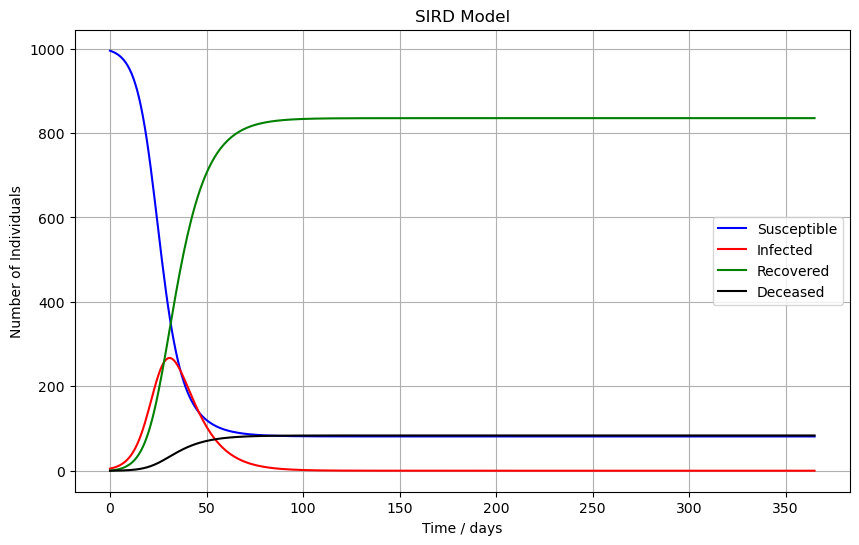

In [7]:
def sird_model(y, t, N, beta, gamma, delta):
    S, I, R, D = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - delta * I
    dRdt = gamma * I
    dDdt = delta * I
    return [dSdt, dIdt, dRdt, dDdt]

# SIRD model parameters
delta = 0.01  # Disease-induced death rate

# Initial conditions
D0 = 0  # initial number of deaths
y0_sird = S0, I0, R0, D0  # Including the initial number of deaths in the initial conditions

# Integrate the SIRD equations over time t
ret_sird = odeint(sird_model, y0_sird, t, args=(N, beta, gamma, delta))
S_sird, I_sird, R_sird, D_sird = ret_sird.T #Transpose the vector

# Plotting the SIRD model results
plt.figure(figsize=(10, 6))
plt.plot(t, S_sird, 'b', label='Susceptible')
plt.plot(t, I_sird, 'r', label='Infected')
plt.plot(t, R_sird, 'g', label='Recovered')
plt.plot(t, D_sird, 'k', label='Deceased')
plt.title('SIRD Model')
plt.xlabel('Time / days')
plt.ylabel('Number of Individuals')
plt.legend()
plt.grid(True)
plt.show()


Try to think about the follow ideas (they may be useful for your RP):

1. Analyze the impact of the disease-induced death rate (`delta`) on the epidemic's dynamics. How does changing `delta` affect the size of the 'Deceased' compartment?
2. Experiment with varying the transmission rate (`beta`) and recovery rate (`gamma`) in the context of the SIRD model. How do these parameters influence the number of deaths and the duration of the epidemic?
3. Consider the ethical implications of modeling disease-induced deaths. Discuss how accurately predicting the number of deaths can aid in public health planning and response.
4. Extend the SIRD model by incorporating a birth rate and a natural death rate. How would you modify the equations to reflect these changes? What impact do these additions have on the model's dynamics? In particular, how would we need to extend our set of equations to include a non-static population, $N$? Models of this type are particularly useful for endemic disease that may affect multiple generations of a species, rather than a fast-moving epidemic like COVID-19. **Enhancing the model in this way may be particularly useful for RP4.**   


## Introduction to the SIS Model

The SIS (Susceptible-Infectious-Susceptible) model is used to describe the dynamics of infectious diseases where individuals do not develop immunity after recovery, making them susceptible to the disease again. This model is particularly relevant for diseases that confer no long-lasting immunity post-infection, such as the common cold.

In this model, the population is divided into two compartments:
- **S (Susceptible):** Individuals who can contract the disease.
- **I (Infectious):** Individuals who have the disease and can transmit it to susceptible individuals.

Individuals move from the susceptible compartment to the infectious compartment when they contract the disease, and return to the susceptible compartment upon recovery. This cycle can continue indefinitely, as recovered individuals do not gain immunity.

### Mathematical Model of SIS Dynamics

The SIS model is governed by the following set of differential equations:

$$
\begin{align*}
\frac{dS}{dt} &= \mu N - \beta \frac{SI}{N} + \gamma I - \mu S, \\
\frac{dI}{dt} &= \beta \frac{SI}{N} - (\gamma + \mu) I,
\end{align*}
$$

where:
- \(N = S + I\) is the total population (assumed constant for simplicity),
- \(\beta\) is the rate of transmission per susceptible and infectious contact,
- \(\gamma\) is the rate of recovery,
- \(\mu\) is the natural per capita death rate, assumed to be equal for all individuals,
- New susceptibles may enter the population through birth at a rate \(\mu N\), keeping the population size constant when considering natural deaths.

This model assumes that the total population size is constant and that the force of infection is proportional to the fraction of the infectious individuals in the population.



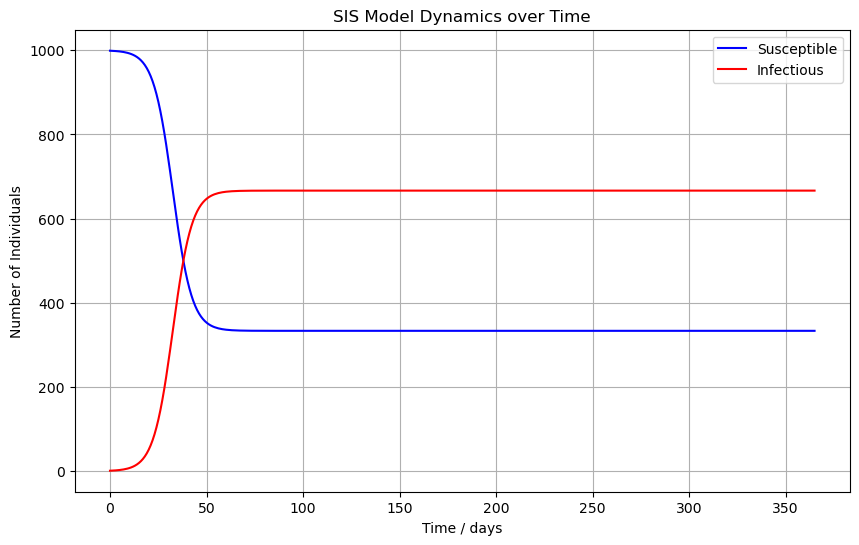

In [8]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters
N = 1000  # Total population
I0 = 1    # Initial number of infectious individuals
S0 = N - I0  # Initial number of susceptible individuals
beta = 0.3  # Transmission rate
gamma = 0.1  # Recovery rate
mu = 0.01 / 365  # Natural death/birth rate per day

# SIS model differential equations
def sis_model(y, t, N, beta, gamma, mu):
    S, I = y
    dSdt = mu * N - beta * S * I / N + gamma * I - mu * S
    dIdt = beta * S * I / N - (gamma + mu) * I
    return [dSdt, dIdt]

# Time vector for simulation
t = np.linspace(0, 365, 365)  # Simulate for 1 year

# Initial conditions vector
y0 = S0, I0

# Integrate the SIS equations over the time grid, t
ret = odeint(sis_model, y0, t, args=(N, beta, gamma, mu))
S, I = ret.T

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(t, S, 'b', label='Susceptible')
plt.plot(t, I, 'r', label='Infectious')
plt.title('SIS Model Dynamics over Time')
plt.xlabel('Time / days')
plt.ylabel('Number of Individuals')
plt.legend()
plt.grid(True)
plt.show()


Try to think about the following ideas (they may be useful for your RP):

1. Experiment with different values of the transmission rate ($\beta$) and recovery rate ($\gamma$). How do these parameters affect the dynamics of the disease within the population?
2. Analyze the impact of introducing a death rate ($\mu$) and a corresponding birth rate to keep the population size constant. How do these rates influence the steady-state of the system?
3. Explore the effects of varying the initial number of infectious individuals ($I_0$) on the spread of the disease. What happens when $I_0$ is a larger fraction of the population?
4. Consider the implications of the SIS model for public health strategies, especially for diseases that do not confer immunity. How might vaccination campaigns influence the dynamics described by the SIS model?


We have seen simple examples of SIR, SEIS (exercise), and SIDS models. Experiment with combining and expanding them. What other compartments could be interesting to consider? For example, one could divide the infectious compartment, $I$, into $I_s$ for symptomatic infectious, and $I_a$ for asymptomatic infectious. How could you adjust the flow rates to account for this? What about a SEIRD model, where after an initial exposed period, infectious individuals either recover, or die?

You may also consider adding other compartments, such as a $V$ compartment for vaccinated individuals.

## Final Remarks 

- Compartment models can be approached in two major ways: either the parameters are determined from observation (and we aim to understand the progression of the disease) or we use known data to "fit" the parameters to the data. Both of these approaches are active areas of research. 
- Parameters can be made "stochastic", i.e. sampled from distributions, to make the models reflect uncertainty in their measurements. This introduces noise (see below)

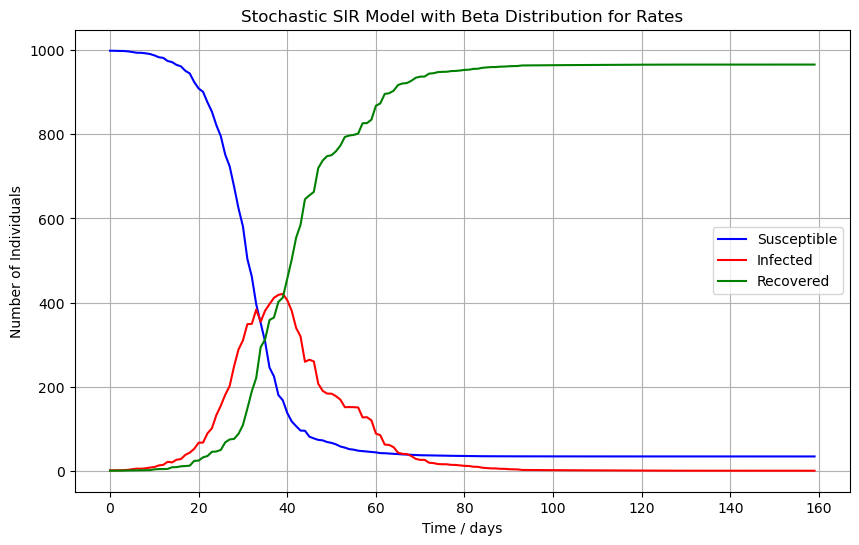

In [12]:
# A stochastic SIR model (optional): 


import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

'''
This is the same as the first model, but instead of 
having beta and gamma as fixed numbers, we sample 
them from a particular distribution. In this 
example, we use a beta distribution for both (https://en.wikipedia.org/wiki/Beta_distribution)
since they must always be betweem 0 and 1, but 
other distributions can be appropriate in 
various situations. 

We very clumsily use odeint in a loop here, but 
it's good enough for this purpose.
'''

from scipy.stats import beta as beta_dist

# Parameters
N = 1000  # Total population
I0 = 1    # Initial number of infected individuals
R0 = 0    # Initial number of recovered individuals
S0 = N - I0 - R0  # Initial number of susceptible individuals

# Shape parameters for the Beta distribution to achieve desired expected values
alpha_beta_for_0_3 = 3  # Alpha parameter for beta distribution targeting an expected value of 0.3
beta_beta_for_0_3 = 7   # Beta parameter for beta distribution targeting an expected value of 0.3
alpha_gamma_for_0_1 = 1 # Alpha parameter for beta distribution targeting an expected value of 0.1
beta_gamma_for_0_1 = 9  # Beta parameter for beta distribution targeting an expected value of 0.1

# SIR model differential equations.
def sir_model_stochastic(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Time vector
t = np.linspace(0, 1, 2)  # Calculate day by day

# Initial conditions
S = [S0]
I = [I0]
R = [R0]

# Simulate over each day
for day in range(1, 160):
    # Sample beta and gamma for each day
    beta_sample = beta_dist.rvs(alpha_beta_for_0_3, beta_beta_for_0_3)
    gamma_sample = beta_dist.rvs(alpha_gamma_for_0_1, beta_gamma_for_0_1)
    
    # Use last state as the initial condition for the next day
    y0 = S[-1], I[-1], R[-1]
    
    # Integrate for this day
    ret = odeint(sir_model_stochastic, y0, t, args=(N, beta_sample, gamma_sample))
    S_end, I_end, R_end = ret[1]  # Get the end of day values
    
    # Append the results
    S.append(S_end)
    I.append(I_end)
    R.append(R_end)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(S, 'b', label='Susceptible')
plt.plot(I, 'r', label='Infected')
plt.plot(R, 'g', label='Recovered')
plt.title('Stochastic SIR Model with Beta Distribution for Rates')
plt.xlabel('Time / days')
plt.ylabel('Number of Individuals')
plt.legend()
plt.grid(True)
plt.show()